# Transpiling Subs into a target gate set

Fault-tolerant quantum programs must ultimately be expressed in the discrete, native gate set of the target architecture. The `quri_parts.qsub.trans` package provides *qsub-native* transpilers that rewrite a `Sub` directly into a chosen gate set: each one consumes a `Sub` and returns a `Sub`, so it drops straight into a qsub workflow with no manual bridging.

Throughout, we reuse two small helpers. `draw_before_after` draws a diagram of the circuit before and after transpilation, and `gate_histogram` counts the gates of a compiled `MachineSub`. Compiling against a primitive gate set only succeeds if every operation resolves into those primitives, so compiling doubles as a check that the transpilation really landed in the target set.

In [1]:
from collections import Counter

from IPython.display import display
from quri_parts.qsub.compile import compile_sub
from quri_parts.qsub.lib import std
from quri_parts.qsub.lib.std import CNOT, H, RZ
from quri_parts.qsub.machineinst import is_subcall
from quri_parts.qsub.sub import SubBuilder
from quri_parts.qsub.visualize import draw


def draw_before_after(before, after):
    print("before:")
    display(draw(before))
    print("after:")
    display(draw(after))


def gate_histogram(machine_sub):
    counter: Counter = Counter()

    def count(msub):
        for op, _qubits, _registers in msub.instructions:
            if is_subcall(op):
                count(op.sub)
            else:
                counter[op.op.id.local_name] += 1

    count(machine_sub)
    return counter

## Clifford+RZ

`CliffordRZSetTranspiler` (from `quri_parts.qsub.trans.clifford_rz`) rewrites a `Sub` into the Clifford group plus the native `RZ` rotation. Keeping `RZ` continuous means no gridsynth approximation is involved: genuine non-Clifford angles are carried through exactly, and only near-Clifford angles are snapped to named gates (tolerance `epsilon`, default `1e-9`). See the [circuit tutorial](../../howto/circuit_compilation/transpiler.ipynb) for the gate-set details.

The sample `Sub` below mixes non-Clifford `RX`/`RY` rotations with an `RZ`; the transpiler rewrites `RX`/`RY` into Clifford gates plus `RZ`, while the genuine `RZ` angles survive.

before:


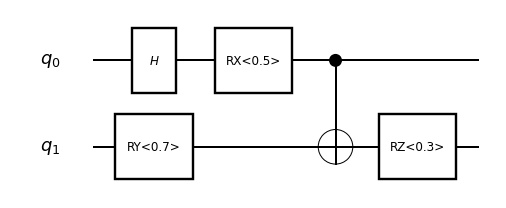

after:


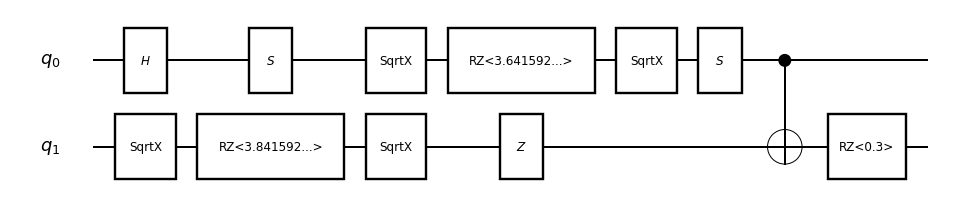

Counter({'SqrtX': 4, 'RZ': 3, 'S': 2, 'H': 1, 'Z': 1, 'CNOT': 1})


In [2]:
from quri_parts.qsub.lib.std import RX, RY
from quri_parts.qsub.trans.clifford_rz import CliffordRZSetTranspiler
from quri_parts.qsub.primitive import CliffordRZ

b = SubBuilder(2)
q0, q1 = b.qubits
b.add_op(H, (q0,))
b.add_op(RX(0.5), (q0,))
b.add_op(RY(0.7), (q1,))
b.add_op(CNOT, (q0, q1))
b.add_op(RZ(0.3), (q1,))
sub = b.build()

transpiled = CliffordRZSetTranspiler()(sub)
compiled = compile_sub(transpiled, CliffordRZ)
draw_before_after(sub, compiled)
print(gate_histogram(compiled))

## STAR ({H, S, RZ, CNOT})

`STARSetTranspiler` (from `quri_parts.qsub.trans.star`) rewrites a `Sub` into the STAR architecture's native set `{H, S, RZ, CNOT}`. Like Clifford+RZ it keeps `RZ` native: `RX`/`RY` are re-expressed with `H`, `S`, and `RZ`, the `RZ` angles are preserved exactly, and no gridsynth approximation is involved — so this transpiler takes no `epsilon`. See the [circuit tutorial](../../howto/circuit_compilation/transpiler.ipynb) for details.

before:


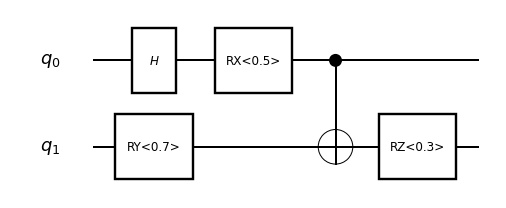

after:


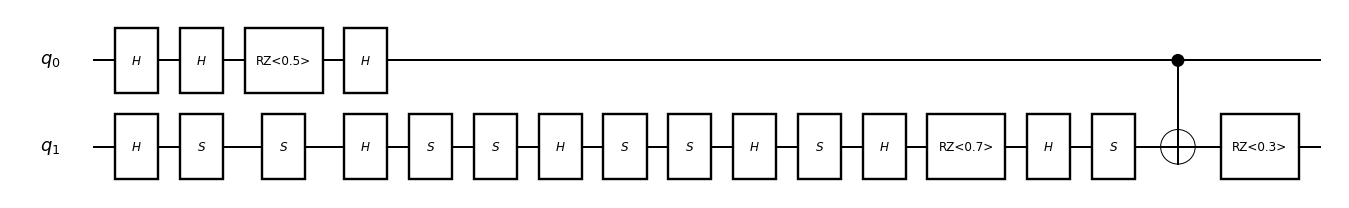

Counter({'H': 9, 'S': 8, 'RZ': 3, 'CNOT': 1})


In [3]:
from quri_parts.qsub.trans.star import STARSetTranspiler

b = SubBuilder(2)
q0, q1 = b.qubits
b.add_op(H, (q0,))
b.add_op(RX(0.5), (q0,))
b.add_op(RY(0.7), (q1,))
b.add_op(CNOT, (q0, q1))
b.add_op(RZ(0.3), (q1,))
sub = b.build()

transpiled = STARSetTranspiler()(sub)
compiled = compile_sub(transpiled, (std.H, std.S, std.RZ, std.CNOT))
draw_before_after(sub, compiled)
print(gate_histogram(compiled))

## Clifford+T

`CliffordTSetTranspiler` (from `quri_parts.qsub.trans.clifford_t`) rewrites a `Sub` into the discrete, universal Clifford+T set. Every `RZ` is approximated into an `{H, S, T}` sequence with gridsynth to precision `epsilon` (default `1e-9`), so no `RZ` survives. By default gridsynth runs through the pure-Python `pygridsynth` package installed with `quri-parts-circuit`; `driver_cli` is available for the external `gridsynth` command. See the [circuit tutorial](../../howto/circuit_compilation/transpiler.ipynb) for the gate set.

The sample `Sub` below uses only `pi/4`-multiple angles, so the conversion is numerically exact to within `epsilon`.

before:


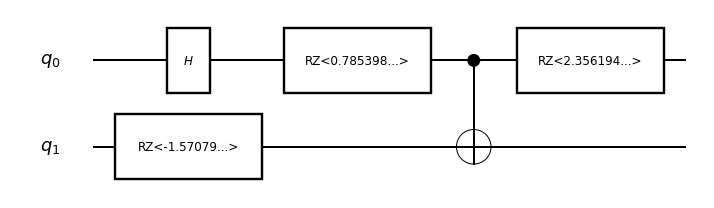

after:


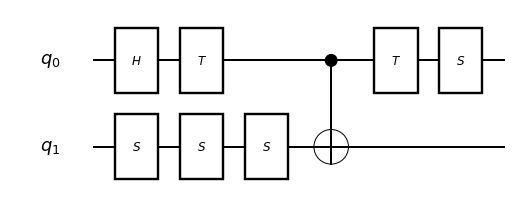

Counter({'S': 4, 'T': 2, 'H': 1, 'CNOT': 1})


In [4]:
from math import pi
from quri_parts.qsub.trans.clifford_t import CliffordTSetTranspiler
from quri_parts.qsub.primitive import CliffordT

b = SubBuilder(2)
q0, q1 = b.qubits
b.add_op(H, (q0,))
b.add_op(RZ(pi / 4), (q0,))
b.add_op(RZ(-pi / 2), (q1,))
b.add_op(CNOT, (q0, q1))
b.add_op(RZ(3 * pi / 4), (q0,))
sub = b.build()

transpiled = CliffordTSetTranspiler()(sub)
compiled = compile_sub(transpiled, CliffordT)
draw_before_after(sub, compiled)
print(gate_histogram(compiled))

For an *arbitrary* angle (not a multiple of `pi/4`), `CliffordTSetTranspiler` approximates the `RZ` into an `{H, S, T}` sequence with gridsynth on its own — no separate transpiler is needed. A larger `epsilon` gives a shorter, less precise sequence. The `RZ(0.3)` below expands into a long, `T`-heavy sequence: around 80 gates even at this loose precision, too wide to draw, so only the histogram is shown.

In [15]:
b = SubBuilder(2)
q0, q1 = b.qubits
b.add_op(H, (q0,))
b.add_op(RZ(0.3), (q0,))
b.add_op(CNOT, (q0, q1))
arb_sub = b.build()

# a larger epsilon keeps the gridsynth approximation short enough to inspect
transpiled = CliffordTSetTranspiler(epsilon=1e-3)(arb_sub)
print(gate_histogram(compile_sub(transpiled, CliffordT)))

Counter({'H': 30, 'T': 29, 'S': 18, 'CNOT': 1})


## FTQC basic set ({H, S, T, CNOT})

`FTQCSetTranspiler` (from `quri_parts.qsub.trans.ftqc`) rewrites a `Sub` into the FTQC basic set `{H, S, T, CNOT}`. Unlike `CliffordTSetTranspiler`, it handles arbitrary-angle rotations in a *single pass*: `pi/4`-multiple angles convert exactly, while arbitrary angles are approximated with gridsynth automatically (precision `epsilon`, default `1e-9`) — no composition with `RZ2HSTTranspiler` needed. See the [circuit tutorial](../../howto/circuit_compilation/transpiler.ipynb) for the underlying gate-set conversion.

First a `Sub` whose `RZ` angles are all `pi/4` multiples (exact conversion):

before:


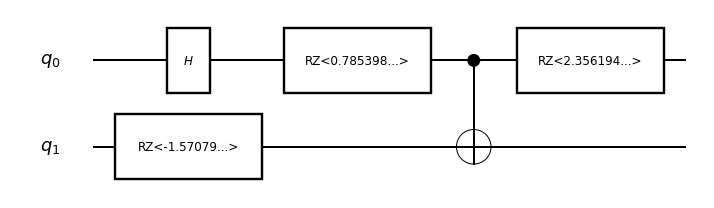

after:


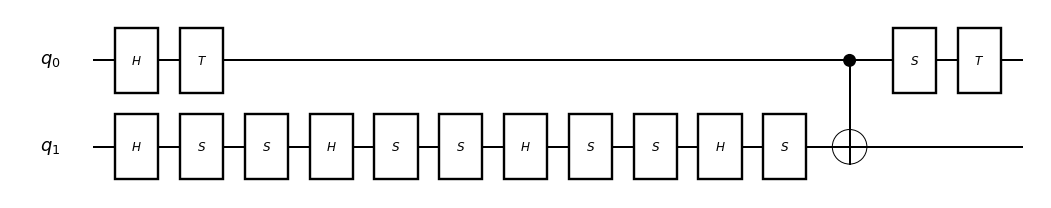

Counter({'S': 8, 'H': 5, 'T': 2, 'CNOT': 1})


In [6]:
from quri_parts.qsub.trans.ftqc import FTQCSetTranspiler
from quri_parts.qsub.primitive import FTQCBasicSet

b = SubBuilder(2)
q0, q1 = b.qubits
b.add_op(H, (q0,))
b.add_op(RZ(pi / 4), (q0,))
b.add_op(RZ(-pi / 2), (q1,))
b.add_op(CNOT, (q0, q1))
b.add_op(RZ(3 * pi / 4), (q0,))
sub = b.build()

transpiler = FTQCSetTranspiler()
compiled = compile_sub(transpiler(sub), FTQCBasicSet)
draw_before_after(sub, compiled)
print(gate_histogram(compiled))

The *same* transpiler also handles an arbitrary angle: the `RZ(0.3)` below is approximated by gridsynth into a long, `T`-heavy `H`/`S`/`T` sequence, with no extra transpiler required. At the default `epsilon` the result runs to a couple of hundred gates, so again only the histogram is shown.

In [14]:
b = SubBuilder(2)
q0, q1 = b.qubits
b.add_op(H, (q0,))
b.add_op(RZ(0.3), (q0,))
b.add_op(CNOT, (q0, q1))
arb_sub = b.build()

print(gate_histogram(compile_sub(transpiler(arb_sub), FTQCBasicSet)))

Counter({'H': 94, 'T': 91, 'S': 52, 'CNOT': 1})


## An arbitrary gate set

The gate sets above have dedicated qsub-native transpilers. For an *arbitrary, user-chosen* target there is none — but none is needed: `compile_sub` (and `compile`) convert a `Sub` into whatever primitive set you compile against by default, using a circuit `GateSetConversionTranspiler` under the hood. So just compile against the target primitives — here `{H, T, CNOT, RZ}`. Keeping `RZ` means arbitrary `Z` rotations stay exact and no gridsynth is needed; `RX`/`RY` are rewritten in terms of the target gates. Choose any gate set by editing the primitives. See the [circuit tutorial](../../howto/circuit_compilation/transpiler.ipynb) for `GateSetConversionTranspiler` and its `epsilon`.

In [ ]:
b = SubBuilder(2)
q0, q1 = b.qubits
b.add_op(H, (q0,))
b.add_op(RX(0.5), (q0,))
b.add_op(RY(0.7), (q1,))
b.add_op(CNOT, (q0, q1))
b.add_op(RZ(0.3), (q1,))
sub = b.build()

# compile_sub converts into the requested primitive set automatically, so no
# explicit transpiler is needed. Keeping RZ in the target avoids gridsynth.
compiled = compile_sub(sub, (std.H, std.T, std.CNOT, std.RZ))
draw_before_after(sub, compiled)
print(gate_histogram(compiled))

ValueError: QuantumGate(name='RX', target_indices=(0,), control_indices=(), classical_indices=(), params=(0.5,), pauli_ids=(), unitary_matrix=()) cannot be converted into the target gateset.